Thư viện vplearn được viết thủ công theo gợi ý thuật toán trong file bài tập, tại đường [link](https://github.com/Dr-Vphuc/Machine_Learning_Library_From_Scratch)

# Ví dụ 1

In [1]:
from vplearn.dimensionality_reduction import PCA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the Iris dataset
df = sns.load_dataset('iris')

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## PCA

In [3]:
X = df.drop('species', axis=1).values
y = df['species'].values

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("Original shape:", X.shape)
print("Transformed shape:", X_pca.shape)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Original shape: (150, 4)
Transformed shape: (150, 2)
Explained variance ratio: [0.72962445 0.22850762]


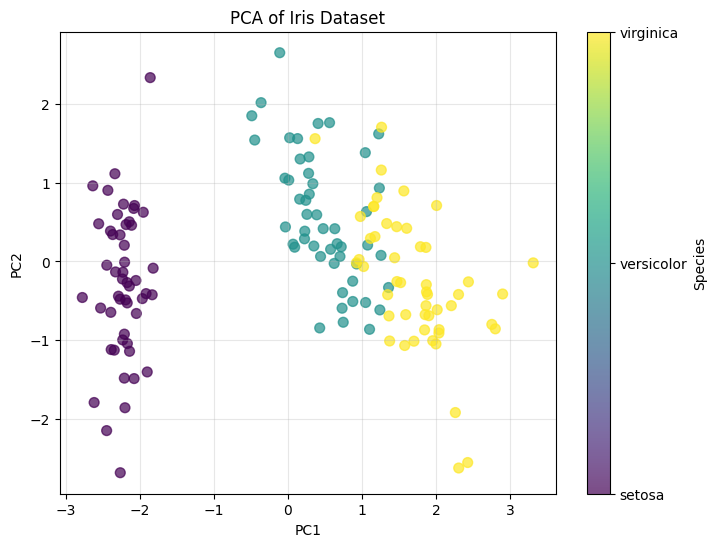

In [4]:
# Create a scatter plot of the PCA-transformed data colored by species
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=pd.Categorical(y).codes, cmap='viridis', s=50, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Iris Dataset')
cbar = plt.colorbar(scatter)
cbar.set_label('Species')
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(['setosa', 'versicolor', 'virginica'])
plt.grid(True, alpha=0.3)
plt.show()

## So sánh Logistic Regression với dữ liệu giảm chiều và dữ liệu gốc

##### Với dữ liệu gốc

In [5]:
training_data = pd.concat([df[:40], df[50:90], df[100:140]], ignore_index=True)
testing_data = pd.concat([df[40:50], df[90:100], df[140:150]], ignore_index=True)

X_train = training_data.drop('species', axis=1).values
y_train = training_data['species'].values
X_test = testing_data.drop('species', axis=1).values
y_test = testing_data['species'].values

In [6]:
from vplearn.classification import LogisticRegression
from vplearn.preprocessing import Encoding
from vplearn.metrics import Accuracy, ConfusionMatrix

encoder = Encoding()
y_encoded = encoder.label_encoding(y_train)

log_reg = LogisticRegression(activate='softmax')

log_reg.fit(X_train, y_encoded)
y_pred = log_reg.predict(X_test)
print("Predicted classes:", y_pred)

# Calculate accuracy
accuracy = Accuracy(encoder.label_encoding(y_test), y_pred)
print("Accuracy:", accuracy)

# Calculate confusion matrix
confusion_matrix = ConfusionMatrix(encoder.label_encoding(y_test), y_pred)
print("Confusion Matrix:")
print(confusion_matrix)

Predicted classes: [0 0 0 0 0 0 0 0 0 0 2 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2]
Accuracy: Accuracy(0.966667)
Confusion Matrix:
ConfusionMatrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


##### Với dữ liệu PCA giảm chiều trước khi chia train/test

In [7]:
X_pca_train = np.array(X_pca[:40].tolist() + X_pca[50:90].tolist() + X_pca[100:140].tolist())
X_pca_test = np.array(X_pca[40:50].tolist() + X_pca[90:100].tolist() + X_pca[140:150].tolist())

In [8]:
from vplearn.classification import LogisticRegression
from vplearn.preprocessing import Encoding
from vplearn.metrics import Accuracy, ConfusionMatrix

encoder = Encoding()
y_encoded = encoder.label_encoding(y_train)

log_reg = LogisticRegression(activate='softmax')

log_reg.fit(X_pca_train, y_encoded)
y_pred = log_reg.predict(X_pca_test)
print("Predicted classes:", y_pred)

# Calculate accuracy
accuracy = Accuracy(encoder.label_encoding(y_test), y_pred) 
print("Accuracy:", accuracy)

# Calculate confusion matrix
confusion_matrix = ConfusionMatrix(encoder.label_encoding(y_test), y_pred)
print("Confusion Matrix:")
print(confusion_matrix)

Predicted classes: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 1]
Accuracy: Accuracy(0.966667)
Confusion Matrix:
ConfusionMatrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


##### Với dữ liệu PCA giảm chiều sau khi chia train/test

In [9]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca_train = pca.transform(X_train)
X_pca_test = pca.transform(X_test)

In [11]:
from vplearn.classification import LogisticRegression
from vplearn.preprocessing import Encoding
from vplearn.metrics import Accuracy, ConfusionMatrix

encoder = Encoding()
y_encoded = encoder.label_encoding(y_train)

log_reg = LogisticRegression(activate='softmax')

log_reg.fit(X_pca_train, y_encoded)
y_pred = log_reg.predict(X_pca_test)
print("Predicted classes:", y_pred)

# Calculate accuracy
accuracy = Accuracy(encoder.label_encoding(y_test), y_pred) 
print("Accuracy:", accuracy)

# Calculate confusion matrix
confusion_matrix = ConfusionMatrix(encoder.label_encoding(y_test), y_pred)
print("Confusion Matrix:")
print(confusion_matrix)

Predicted classes: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 1]
Accuracy: Accuracy(0.966667)
Confusion Matrix:
ConfusionMatrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


### Để tránh leakage, em sẽ chỉ fit PCA trên training data, sau đó transform cả training và test data bằng PCA đã fit trên training data.

# Ví dụ 2

In [54]:
from pathlib import Path

DATA_PATH = str(Path('data')) + '/pd_speech_features.csv'

df = pd.read_csv(DATA_PATH, index_col=0)
df.head(5)

,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,locAbsJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
id,,,,,,,,,,,,,,,,,,,,,
0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,0.000018,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,0.000016,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,0.000015,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,0.000046,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,0.000044,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


In [19]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df.iloc[:, :-1].values)

print("Original shape:", df.iloc[:, :-1].values.shape)
print("Transformed shape:", X_pca.shape)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Original shape: (756, 753)
Transformed shape: (756, 2)
Explained variance ratio: [0.12961998 0.09390046]


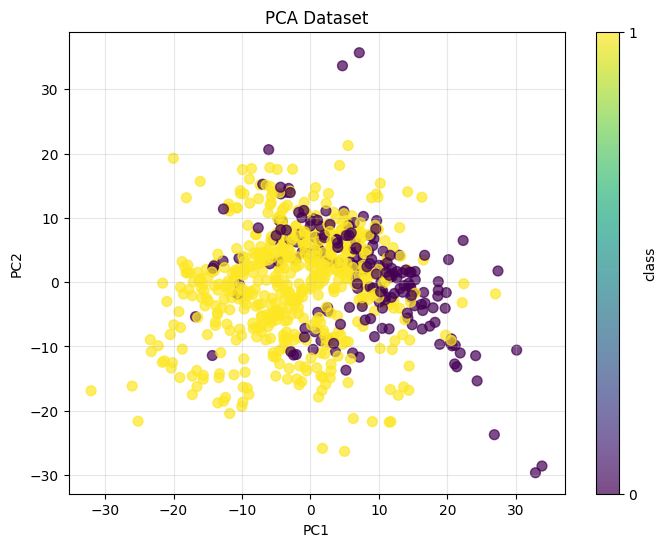

In [44]:
# Create a scatter plot of the PCA-transformed data colored by species
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=pd.Categorical(df.iloc[:, -1]).codes, cmap='viridis', s=50, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Dataset')
cbar = plt.colorbar(scatter)
cbar.set_label('class')
cbar.set_ticks([0, 1])
plt.grid(True, alpha=0.3)
plt.show()

# Bài tập thực hành 1

##### Chia train/test trước rồi PCA

In [27]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train = X[:500]
y_train = y[:500]
X_test = X[500:]
y_test = y[500:]

pca = PCA(n_components=200)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

log_reg = LogisticRegression(activate='sigmoid')
log_reg.fit(X_train_pca, y_train)
y_pred = log_reg.predict(X_test_pca)

accuracy = Accuracy(y_test, y_pred)
print("Accuracy:", accuracy)

confusion_matrix = ConfusionMatrix(y_test, y_pred)
print("Confusion Matrix:")
print(confusion_matrix)

Accuracy: Accuracy(0.800781)
Confusion Matrix:
ConfusionMatrix:
[[ 55  26]
 [ 25 150]]


F:\Learning\ML\vplearn\classification\logistic_regression.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  X_train = self._convert_to_numpy(X).astype(float)
F:\Learning\ML\vplearn\classification\logistic_regression.py:77: ComplexWarning: Casting complex values to real discards the imaginary part
  s = np.asarray(s, dtype=np.float64)


##### PCA trước rồi chia train/test

In [26]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

pca = PCA(n_components=200)
X_pca_all = pca.fit_transform(X)
X_pca_all = np.real(X_pca_all) 

X_train_pca = X_pca_all[:500]
y_train = y[:500]
X_test_pca = X_pca_all[500:]
y_test = y[500:]

log_reg = LogisticRegression(activate='sigmoid')
log_reg.fit(X_train_pca, y_train)
y_pred = log_reg.predict(X_test_pca)

accuracy = Accuracy(y_test, y_pred)
print("Accuracy:", accuracy)

confusion_matrix = ConfusionMatrix(y_test, y_pred)
print("Confusion Matrix:")
print(confusion_matrix)

Accuracy: Accuracy(0.753906)
Confusion Matrix:
ConfusionMatrix:
[[ 59  22]
 [ 41 134]]


#### TH 1 tốt hơn

##### Giữ 80% variance 

In [39]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train = X[:500]
y_train = y[:500]
X_test = X[500:]
y_test = y[500:]

pca = PCA(n_components=54)
X_train_pca = pca.fit_transform(X_train)
print("Sum of Explained variance ratio:", round(np.sum(pca.explained_variance_ratio_).astype(float), 4))
X_test_pca = pca.transform(X_test)

log_reg = LogisticRegression(activate='sigmoid')
log_reg.fit(X_train_pca, y_train)
y_pred = log_reg.predict(X_test_pca)

accuracy = Accuracy(y_test, y_pred)
print("Accuracy:", accuracy)

confusion_matrix = ConfusionMatrix(y_test, y_pred)
print("Confusion Matrix:")
print(confusion_matrix)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20640\2019349550.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  print("Sum of Explained variance ratio:", round(np.sum(pca.explained_variance_ratio_).astype(float), 4))


Sum of Explained variance ratio: 0.8009
Accuracy: Accuracy(0.746094)
Confusion Matrix:
ConfusionMatrix:
[[ 50  31]
 [ 34 141]]


Để dữ 80% variance, ta chỉ cần 54 thành phần chính. Accuracy giảm so với giữ 200 thành phần chính.

Thử với Logistic Regression và Naive Bayes.

In [46]:
# Dữ liệu gốc
from vplearn.preprocessing import train_test_split
from vplearn.classification import LogisticRegression
from vplearn.classification.naive_bayes import GaussianNB
from vplearn.metrics import Accuracy, ConfusionMatrix
import ast

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression(activate='sigmoid')
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_nb = gnb.predict(X_test)

accuracy_log = Accuracy(y_test, y_pred_log)
accuracy_nb = Accuracy(y_test, y_pred_nb)
confusion_matrix_log = ConfusionMatrix(y_test, y_pred_log)
confusion_matrix_nb = ConfusionMatrix(y_test, y_pred_nb)

print("Logistic Regression Accuracy:", accuracy_log)
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix_log)

print("Naive Bayes Accuracy:", accuracy_nb)
print("Naive Bayes Confusion Matrix:")
print(confusion_matrix_nb)

Logistic Regression Accuracy: Accuracy(0.754967)
Logistic Regression Confusion Matrix:
ConfusionMatrix:
[[  0  37]
 [  0 114]]
Naive Bayes Accuracy: Accuracy(0.245033)
Naive Bayes Confusion Matrix:
ConfusionMatrix:
[[ 37   0]
 [114   0]]


In [53]:
# Dữ liệu gốc
from vplearn.preprocessing import train_test_split
from vplearn.classification import LogisticRegression
from vplearn.classification.naive_bayes import GaussianNB
from vplearn.metrics import Accuracy, ConfusionMatrix
import ast

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

log_reg = LogisticRegression(activate='sigmoid')
log_reg.fit(X_train_pca, y_train)
y_pred_log = log_reg.predict(X_test_pca)

gnb = GaussianNB()
gnb.fit(X_train_pca, y_train)
y_pred_nb = gnb.predict(X_test_pca)

accuracy_log = Accuracy(y_test, y_pred_log)
accuracy_nb = Accuracy(y_test, y_pred_nb)
confusion_matrix_log = ConfusionMatrix(y_test, y_pred_log)
confusion_matrix_nb = ConfusionMatrix(y_test, y_pred_nb)

print("Logistic Regression Accuracy:", accuracy_log)
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix_log)

print("Naive Bayes Accuracy:", accuracy_nb)
print("Naive Bayes Confusion Matrix:")
print(confusion_matrix_nb)

F:\Learning\ML\vplearn\classification\logistic_regression.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  X_train = self._convert_to_numpy(X).astype(float)
F:\Learning\ML\vplearn\classification\logistic_regression.py:77: ComplexWarning: Casting complex values to real discards the imaginary part
  s = np.asarray(s, dtype=np.float64)
f:\Learning\ML\.venv\lib\site-packages\numpy\_core\_methods.py:52: ComplexWarning: Casting complex values to real discards the imaginary part
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Logistic Regression Accuracy: Accuracy(0.774834)
Logistic Regression Confusion Matrix:
ConfusionMatrix:
[[26 11]
 [23 91]]
Naive Bayes Accuracy: Accuracy(0.741722)
Naive Bayes Confusion Matrix:
ConfusionMatrix:
[[  4  33]
 [  6 108]]


- Thực hiện phân loại bằng cả hai pp trên PCA đều cho kết quả tốt hơn, với 754 trường dữ liệu thì gần như mô hình chỉ đoán mò duy nhất vào 1 trường. 
- Trên PCA, Logistic Regression nhỉnh hơn Naive Bayes với accuracy 0.77 so với 0.74. Còn việc mô hình nào có sự thay đổi nhiều hơn thì không thể đánh giá được vì tại bộ dữ liệu gốc cả 2 đều đoán mò duy nhất vào 1 class (accuracy khác nhau là do chênh lệch class trong tập test).

# Ví dụ 3

In [60]:
from pathlib import Path

DATA_PATH = Path('data') / 'vidu4_lin_reg.txt'
with open(DATA_PATH) as f:
    line = f.readline()
    
    df = []
    while line != '':
        line = f.readline().replace('\n', '')
        tokens = line.split(' ')
        array = tokens[1:]
        if array != []:
            df.append(array)
    
    df = np.array(df, dtype=np.float32)

X = df[:, :-1]
y = df[:, -1].reshape(-1, 1)


Original shape: (100, 5)
Transformed shape: (100, 2)
Explained variance ratio: [0.26605725 0.22664618]


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20640\747062732.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='viridis', s=50, alpha=0.7)


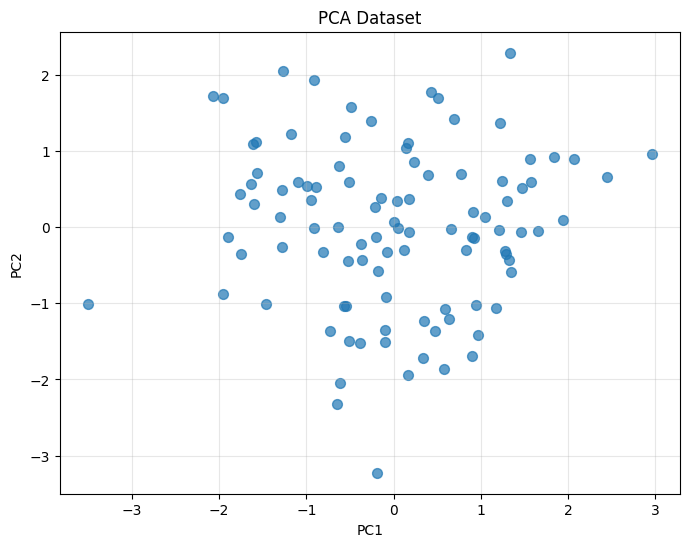

In [61]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Original shape:", X.shape)
print("Transformed shape:", X_pca.shape)

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='viridis', s=50, alpha=0.7)
plt.xlabel('PC1')  
plt.ylabel('PC2')
plt.title('PCA Dataset')
plt.grid(True, alpha=0.3)
plt.show()

In [63]:
from vplearn.regression import LinearRegression
from vplearn.metrics import MSE

X_train = X[:80]
y_train = y[:80]
X_test = X[80:]
y_test = y[80:]
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

lm = LinearRegression()
lm.fit(X_train_pca, y_train)
y_pred = lm.predict(X_test_pca)

mse = MSE(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: MSE(0.305977)


In [64]:
lm_origin = LinearRegression()
lm_origin.fit(X_train, y_train)
y_pred_origin = lm_origin.predict(X_test)
mse_origin = MSE(y_test, y_pred_origin)
print("Mean Squared Error (Original):", mse_origin)

Mean Squared Error (Original): MSE(0.325424)


##### MSE của mô hình hồi quy tuyến tính trên dữ liệu PCA tốt hơn so với dữ liệu gốc. Điều này có thể do PCA giúp loại bỏ nhiễu và giảm chiều dữ liệu, làm cho mô hình hồi quy tuyến tính dễ dàng học được mối quan hệ giữa các biến độc lập và biến phụ thuộc hơn.